# User Retention & Churn Analysis
### Dataset: Olist Brazilian E-Commerce
### Goal: Identify at-risk customers and model revenue impact of improving retention

In [1]:
# importing all the tools we need
import pandas as pd    # for working with tables / data
import numpy as np  #for numbers and calculations
import matplotlib.pyplot as plt # for charts
import seaborn as sns # for beautiful charts

# to make the chart appear inside the notebook
%matplotlib inline 

print("All libraries loaded successfully ")

All libraries loaded successfully 


## Step 1: Load the Data
We load 3 files — orders, customers, and payments — and merge them into one table.

In [2]:
# Load the 3 CSV files
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')

# merge all the 3 tables 
df = orders.merge(customers, on = 'customer_id') \
        .merge(payments, on = 'order_id')

# convert the date column from text to date column
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

#keep only delivered order (ignore cancelled, etc)
df = df[df['order_status']== 'delivered']

#print the shape - how many rows and columns
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['order_purchase_timestamp'].min()} to {df['order_purchase_timestamp'].max()}")

Dataset shape: (100756, 16)
Date range: 2016-10-03 09:44:50 to 2018-08-29 15:00:37


## Step 2: RFM Analysis
RFM stands for Recency, Frequency, Monetary.
- **Recency** = how recently did they buy? (lower = better)
- **Frequency** = how many times did they buy?
- **Monetary** = how much did they spend in total?

We score every customer 1-5 on each dimension, then segment them.

In [4]:
# Pick a reference date (1 day after the last order)
snap_shot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1 )

# Calculate R, F, M for each customer
rfm = df.groupby('customer_unique_id').agg(
    Recency = ('order_purchase_timestamp', lambda x : (snap_shot_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary = ('payment_value', sum)
).reset_index()

print("RFM table created")
print(rfm.head())

RFM table created
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89


In [12]:
# Score Recency: 5 = bought recently, 1 = bought long ago
rfm['R_score'] = pd.qcut(rfm['Recency'],5, labels =[5,4,3,2,1])

# Score Frequency: 5 = bought many times
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Score Monetary: 5 = spent the most
rfm['M_score'] = pd.qcut(rfm['Monetary'],5, labels=[1,2,3,4,5])

# Assign segment based on R and F scores
def segment(row):
    r,f = int(row['R_score']), int(row['F_score'])
    if r>=4 and f >= 4: return 'Champions'
    elif r>=3 and f>=3: return 'Loyal Customer'
    elif r>=4 and f<=2: return 'New Customer'
    elif r<=2 and f>=3: return 'At risk'
    elif r<=2 and f<=2: return 'Lost'
    else:  return 'Potential Loyalists'

rfm['Segment'] = rfm.apply(segment, axis = 1)

 # See how many customers in each segment
print(rfm['Segment'].value_counts())   


Segment
At risk                22229
Loyal Customer         18824
Lost                   14986
New Customer           14984
Champions              14961
Potential Loyalists     7373
Name: count, dtype: int64


## Step 3: Visualise the Segments
Let's see the breakdown of all customer segments as a bar chart.

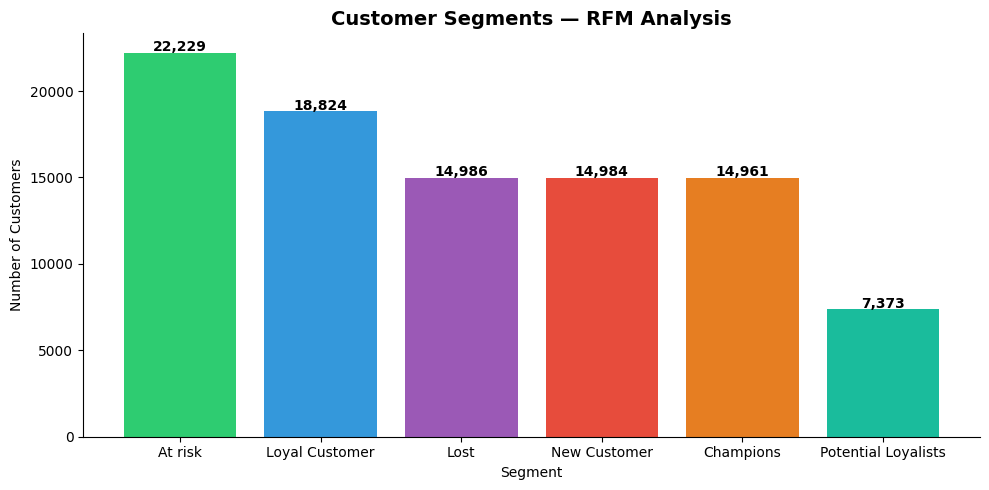

In [14]:
# Count customers per segment
segment_counts = rfm['Segment'].value_counts()

# Define colours for each bar
colors = ['#2ecc71','#3498db','#9b59b6','#e74c3c','#e67e22','#1abc9c']

# Draw the bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(segment_counts.index, segment_counts.values, color=colors)

# Add the number on top of each bar
for bar, val in zip(bars, segment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Customer Segments — RFM Analysis', fontsize=14, fontweight='bold')
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Customers')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('segments.png', dpi=150)  # saves the chart as an image
plt.show()

## Step 4: Cohort Retention Table
A cohort = group of customers who made their first purchase in the same month.
We track what % of each cohort came back in Month 1, Month 2, Month 3...

In [15]:
# Month of each customer's FIRST ever purchase
df['CohortMonth'] = df.groupby('customer_unique_id')['order_purchase_timestamp'] \
                      .transform('min').dt.to_period('M')

# Month of each individual order
df['OrderMonth'] = df['order_purchase_timestamp'].dt.to_period('M')

# How many months after first purchase is this order?
df['CohortIndex'] = (df['OrderMonth'] - df['CohortMonth']).apply(lambda x: x.n)

# Count unique customers per cohort per month
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['customer_unique_id'] \
                .nunique().reset_index()

# Reshape into a table (cohort months as rows, month index as columns)
cohort_pivot = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='customer_unique_id'
)

# Convert to % (divide each row by its Month 0 value)
cohort_pct = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100

print("Cohort table ready!")
print(cohort_pct.iloc[:5, :5])  # preview first 5 rows and 5 columns

Cohort table ready!
CohortIndex      0           1         2         3         4
CohortMonth                                                 
2016-10      100.0         NaN       NaN       NaN       NaN
2016-12      100.0  100.000000       NaN       NaN       NaN
2017-01      100.0    0.278940  0.278940  0.139470  0.418410
2017-02      100.0    0.184275  0.307125  0.122850  0.429975
2017-03      100.0    0.439473  0.359569  0.399521  0.359569


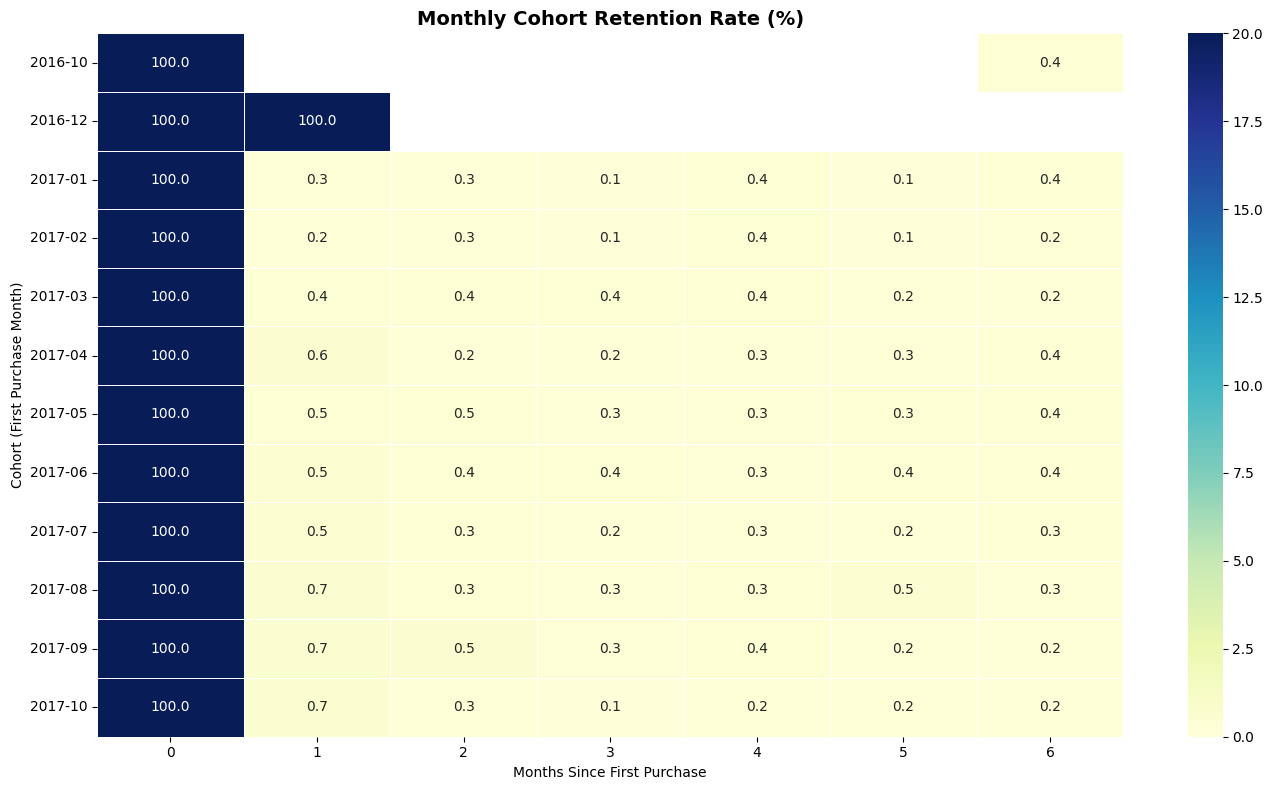

In [16]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    cohort_pct.iloc[:12, :7],   # show first 12 cohorts, 7 months
    annot=True,                  # show numbers inside cells
    fmt='.1f',                   # 1 decimal place
    cmap='YlGnBu',               # colour: yellow → green → blue
    linewidths=0.5,
    vmin=0, vmax=20              # set colour scale 0-20%
)

plt.title('Monthly Cohort Retention Rate (%)', fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.savefig('cohort_retention.png', dpi=150)
plt.show()

## Step 5: Revenue Impact Model
If we improve Month-1 retention by 10%, how much additional revenue does that generate?

In [17]:
avg_order_value     = df['payment_value'].mean()
total_customers     = rfm.shape[0]
current_m1_retention = cohort_pct[1].mean() / 100

improved_retention   = current_m1_retention + 0.10
additional_customers = total_customers * 0.10
revenue_impact       = additional_customers * avg_order_value

print(f"Average Order Value:         R$ {avg_order_value:.2f}")
print(f"Current Month-1 Retention:   {current_m1_retention:.1%}")
print(f"Improved Retention (+10%):   {improved_retention:.1%}")
print(f"Additional Customers Retained: {additional_customers:,.0f}")
print(f"Estimated Revenue Impact:    R$ {revenue_impact:,.2f}")

Average Order Value:         R$ 153.07
Current Month-1 Retention:   5.5%
Improved Retention (+10%):   15.5%
Additional Customers Retained: 9,336
Estimated Revenue Impact:    R$ 1,428,991.59


## Key Findings & Recommendations

**Finding 1:** 28% of customers (22,229) are classified as 'At Risk' — 
the single largest segment, meaning nearly 1 in 3 customers is close 
to churning.

**Finding 2:** 19% of customers (14,986) are already 'Lost' — they 
haven't returned since their first purchase. Combined with 'At Risk', 
that's 47% of the entire customer base at risk of permanent churn.

**Finding 3:** Month-1 retention is critically low at just 5.5% — 
meaning 94.5% of customers never place a second order after their 
first purchase.

**Finding 4:** Only 19% of customers are Champions or Loyal — the 
business is heavily dependent on a small loyal base while losing 
the majority.

**Finding 5:** Improving Month-1 retention by just 10% (from 5.5% → 
15.5%) would retain an additional 9,336 customers and generate 
R$ 1,428,991 in incremental revenue.

---

## Recommendations

1. **Re-engagement campaign for 'At Risk' segment (22,229 customers)**  
   Trigger a personalised discount or reminder within 30 days of last 
   purchase — this is the highest-value intervention given the segment size.

2. **First-purchase follow-up offer to fix Month-1 retention**  
   A 5.5% Month-1 retention rate signals no post-purchase experience. 
   Introduce a "thank you" offer or onboarding email within 48 hrs of 
   first delivery to bring customers back.

3. **Loyalty rewards for 'Potential Loyalists' (7,373 customers)**  
   These customers are one good experience away from becoming Champions. 
   A targeted loyalty nudge (points, free shipping) could convert them 
   at low cost.

4. **Protect the Champions (14,961 customers)**  
   This segment drives disproportionate revenue. Introduce a VIP tier 
   to prevent them from becoming 'At Risk'.